# Jordan Titanic Data Features
**Author:** Jordan  
**Date:** October 31, 2025 <br>
**Objective:** Data inspection, exploration, and preparation for training/test splits.


## Introduction
This project uses seaborn's Titanic dataset to demonstrate pre-processing of data before splitting for analysis and to compare splitting methods.  We will inspect and clean the data before comparing standard pseudo-random splitting to stratified spliting.

## Imports
First, we import the necessary Python libraries for our analysis. 

In [2]:
import matplotlib.pyplot as plt
from numpy.linalg import cond
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from statsmodels.stats.stattools import medcouple

from stats_jordan import tukey_fences

## Section 1. Load and Inspect the Data

### 1.1 Load the Dataset
Next, we load the Mushroom dataset from seaborn and view its head.

In [ ]:
titanic_df: pd.DataFrame = sns.load_dataset('titanic')  # noqa: Q000

titanic_df.head(10)
# Load the mushroom dataset
mushroom_df: pd.DataFrame = pd.read_csv("data/agaricus-lepiota.data", header=None, na_values="?")
# Display the first 10 rows of the dataset
mushroom_df.columns = ["poisonous", "cap-shape", "cap-surface", "cap-color", "bruises?", "odor",
                       "gill-attachment", "gill-spacing", "gill-size", "gill-color", "stalk-shape",
                       "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring",
                       "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color",
                       "ring-number", "ring-type", "spore-print-color", "population", "habitat"]

mushroom_df.head(10)
print(1)

,poisonous,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,...,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,s,m


### 1.2 Preliminary Inspection

Then, we check for missing values, display summary statistics, and check for correlations.

In [4]:
# Check data types and missing values
mushroom_df.info(verbose=True)
# Summary statistics
display(mushroom_df.describe())
# Check for missing values
display(mushroom_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   poisonous                 8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises?                  8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                5644 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

,poisonous,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


poisonous                      0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises?                       0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

### Reflection 1:

1) What do you notice about the dataset? 
2) Are there any data issues?

## Section 2. Explore data patterns and distributions

Now, we will explore our dataset with charts.  Depending on what we learn, cleaning and/or feature engineering may be in order.

odor, gill size, spore print color

### 2.1 Create Scatter Matrix, Scatter Plot, Histogram and Count Plot

We create a scatter matrix for the numeric attributes.

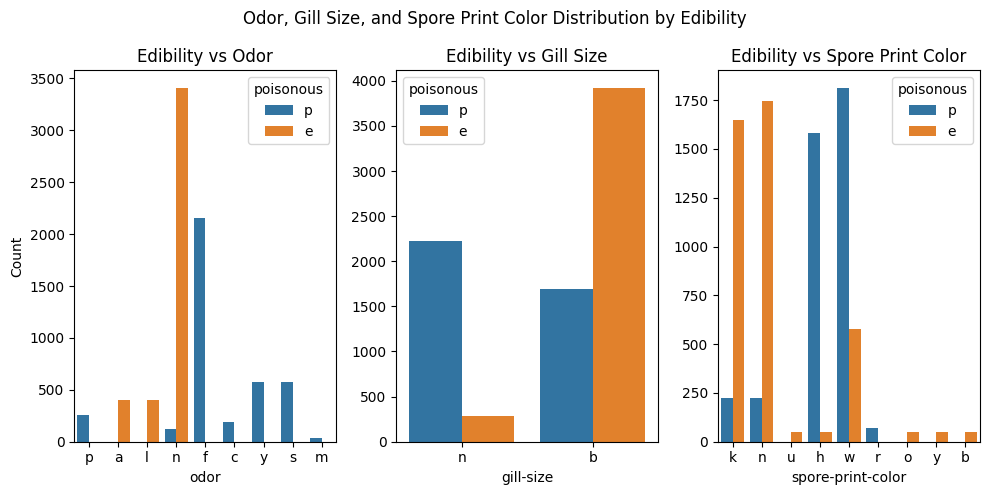

In [27]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10,5))

for ax, name in zip(axes.flatten(), ("odor", "gill-size", "spore-print-color"), strict=True):

    sns.countplot(x=name, hue="poisonous", data=mushroom_df, ax=ax)
    ax.set_title(f"Edibility vs {name.replace("-", " ").title()}")
    ax.set_ylabel("Count") if ax is axes[0] else ax.set_ylabel("")

fig.suptitle("Odor, Gill Size, and Spore Print Color Distribution by Edibility")
plt.tight_layout()
plt.show()

Column labels in order: ['e', 'p']


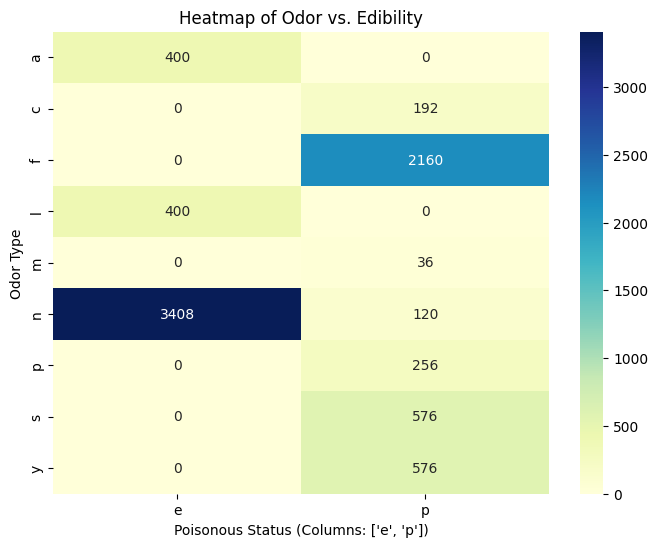

In [23]:
contingency_table = pd.crosstab(mushroom_df['odor'], mushroom_df['poisonous'])

# Explicitly print the column order to be certain
print("Column labels in order:", contingency_table.columns.tolist()) 

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Odor vs. Edibility')
plt.xlabel(f"Poisonous Status (Columns: {contingency_table.columns.tolist()})") # Dynamically set xlabel
plt.ylabel('Odor Type')
plt.show()

By both the scatter matrix plot and numerical tesing, the 'fare' feature is heavily positively skewed.  Let's assess 'fare' for outliers.

### 2.2 Handle Missing Values and Clean Data

The 'age' and 'embark_town' features had missing values, so we impute missing age values using the median and fill missing 'embark_town' values with the mode.

In [143]:
titanic_df['age'] = titanic_df['age'].fillna(titanic_df['age'].median())  # noqa: Q000
titanic_df['embark_town'] = titanic_df['embark_town'].fillna(titanic_df['embark_town'].mode()[0])  # noqa: Q000

### 2.3 Feature Engineering
We now create a new feature, 'family_size'.  Then, we convert categorical data to numeric and create a binary feature for 'alone'.

In [144]:
titanic_df['family_size'] = titanic_df['sibsp'] + titanic_df['parch'] + 1  # noqa: Q000
titanic_df['sex'] = titanic_df['sex'].map({'male': 0, 'female': 1})  # noqa: Q000
titanic_df['embarked'] = titanic_df['embarked'].map({'C': 0, 'Q': 1, 'S': 2})  # noqa: Q000
titanic_df['alone'] = titanic_df['alone'].astype(int)  # noqa: Q000

### Reflection 2:

What patterns or anomalies do you see? Do any features stand out? What preprocessing steps were necessary to clean and improve the data? Did you create or modify any features to improve performance?



## Section 3. Choose Features and Target

With classification in mind, we now select input and target features for our model.


In [145]:
features: list = ["age", "fare", "pclass", "sex", "family_size"]
target: str = "survived"
X: pd.DataFrame = titanic_df[features]  # noqa: N816
y: pd.Series = titanic_df[target]

Reflection 3:

1) Why are these features selected?  <br>These features were selected based on the demographics of the surviving passengers during the sinking of the Titanic, where women, children and the wealthy (first-class passengers who paid more fare) were granted preferential treatment in boarding the life boats.
2) Are there any features that are likely to be highly predictive of survival?  <br>Yes, the feature selection of 'age', 'fare', 'pclass', and 'sex' are likely to be highly predictive of survival due to them capturing the demographic features that influenced who boarded the life boats as mentioned above.

## Section 4. Splitting

We will now split the data into training and test sets using train_test_split first and StratifiedShuffleSplit second.  Then a comparison of the results will be performed.


In [146]:
X_train_basic, X_test_basic, y_train_basic, y_test_basic = train_test_split(X, y, test_size=0.2, random_state = 123)
print(f"""
Train size: {len(X_train_basic)}
Test size:  {len(X_test_basic)}
""")


Train size: 712
Test size:  179



In [147]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_ind, test_ind in splitter.split(X, y):
    X_train_stratified = X.iloc[train_ind]
    X_test_stratified = X.iloc[test_ind]
    y_train_stratified = y.iloc[train_ind]
    y_test_stratified = y.iloc[test_ind]

print(f"""
Train size: {len(X_train_stratified)}
Test size:  {len(X_test_stratified)}
""")


Train size: 712
Test size:  179



In [148]:
print("Original Class Distribution:\n", y.value_counts(normalize=True))
print("Train Set Class Distribution:\n", X_train_stratified["pclass"].value_counts(normalize=True))
print("Test Set Class Distribution:\n", X_test_stratified["pclass"].value_counts(normalize=True))

Original Class Distribution:
 survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
Train Set Class Distribution:
 pclass
3    0.561798
1    0.227528
2    0.210674
Name: proportion, dtype: float64
Test Set Class Distribution:
 pclass
3    0.508380
1    0.301676
2    0.189944
Name: proportion, dtype: float64


### Reflection 4

1) Why might stratification improve model performance?  
   <br>Stratification splits the testing and training sets in proportion to the original target features classes.  This is particulary important for imbalanced datasets, where a model could be trained on a biased sample do to a misbalanced splitting of one or several classes within the target feature.  This can lead to the model performing well for some classes in the target feature and poorly for others.
   
2) How close are the training and test distributions to the original dataset?

In [149]:
data_splits = {
    "Training Stratified": y_train_stratified,
    "Training Basic": y_train_basic,
    "Test Stratified": y_test_stratified,
    "Test Basic": y_test_basic
}
proportions: pd.Series = y.value_counts(normalize=True)

for name, split in data_splits.items():
    split_error: pd.Series = abs(split.value_counts(normalize=True) - proportions) / proportions * 100

    for index in split_error.index:
        text: str = f"{name} Split Percent Error for Class {index}:"
        print(f"{text:<53} {split_error[index]:>.2f}%")

Training Stratified Split Percent Error for Class 0:  0.07%
Training Stratified Split Percent Error for Class 1:  0.11%
Training Basic Split Percent Error for Class 0:       0.84%
Training Basic Split Percent Error for Class 1:       1.36%
Test Stratified Split Percent Error for Class 0:      0.27%
Test Stratified Split Percent Error for Class 1:      0.43%
Test Basic Split Percent Error for Class 0:           3.36%
Test Basic Split Percent Error for Class 1:           5.40%


3) Which split method produced better class balance?
   
The stratified split method provided a significantly better class balance. All percent errors for the stratified split were consistently low, with a max error of only 0.43%. In contrast, the basic split method resulted in much higher percent errors, ranging from 0.84% to 5.40%.